<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB28 · Probabilidad desde cero

**Parte 4 · Aprendizaje por refuerzo de verdad — Lección 1**

> Terminaste el bloque de Python. Volvemos a la robótica, y a lo grande: empieza la parte en la que el robot va a aprender **de verdad**,
> **sin maestro**, solo con recompensas. Pero antes necesitamos una herramienta matemática que llevamos todo el curso rozando sin
> nombrarla: la **probabilidad**.

¿Dónde aparece el azar en el aprendizaje por refuerzo? En **dos** sitios, y los dos son esenciales:

1. **En el mundo.** El viento del palo de escoba, los empujones al robot, el ruido de los sensores (NB01, NB11). El mismo robot con la misma
   política puede sacar 499 puntos en un episodio y 150 en otro. Hay que saber **medir** con azar (en el NB27 viste que 5 episodios engañan).
2. **En la mente.** En el NB03 dijimos que una política que aprende tiene que **explorar**: probar acciones un poco distintas de las que cree
   mejores, añadiendo un poco de azar. El algoritmo del próximo notebook, REINFORCE, **necesita** que la política sea "con azar" para poder
   aprender.

Hoy construiremos la probabilidad desde cero: qué es, cómo se describe el azar con números, la famosa **campana de Gauss**, cuánto fiarse de una
media, y cómo se construye una política que explora. Con muchos experimentos, porque la probabilidad se entiende **simulando**.


## 1 · ¿Qué es la probabilidad?

Lanza una moneda. ¿Saldrá cara o cruz? No lo sabes. Pero sí sabes algo: si la lanzas **muchísimas** veces, saldrá cara más o menos **la mitad**
de las veces. Esa es la idea de probabilidad:

> **La probabilidad de algo es la proporción de veces que pasa, si repitieras la situación muchísimas veces.**

Se escribe como un número entre **0** (imposible: nunca pasa) y **1** (seguro: pasa siempre), o como un porcentaje. La probabilidad de cara es
**0,5** (50 %). La de sacar un 6 con un dado, **1/6** (unos 0,167, el 16,7 %): de cada seis tiradas, una, a la larga.

Comprobémoslo **simulando**. Python puede "lanzar" un dado con un generador de azar de NumPy (NB27): `integers(1, 7, size=n)` da `n` números
enteros al azar del 1 al 6 (el 7 no entra, como en `range`):


In [1]:
import numpy as np
import matplotlib.pyplot as plt

generador = np.random.default_rng(0)
tiradas = generador.integers(1, 7, size=12)
print(tiradas)
print("Proporción de seises en 12 tiradas:", (tiradas == 6).mean())

[6 4 4 2 2 1 1 1 2 5 4 6]
Proporción de seises en 12 tiradas: 0.16666666666666666


En 12 tiradas, la proporción de seises puede salir cualquier cosa (con tan pocas, el azar manda; aquí, por casualidad, han salido 2 seises, justo 1/6, pero con
otra semilla podrían salir 0, o 5). Pero ¿qué pasa con **muchas**? Vamos a tirar el dado
100.000 veces y a dibujar cómo va cambiando la proporción de seises a medida que acumulamos tiradas (con `np.cumsum`, que va sumando acumulando: la
**suma acumulada**):


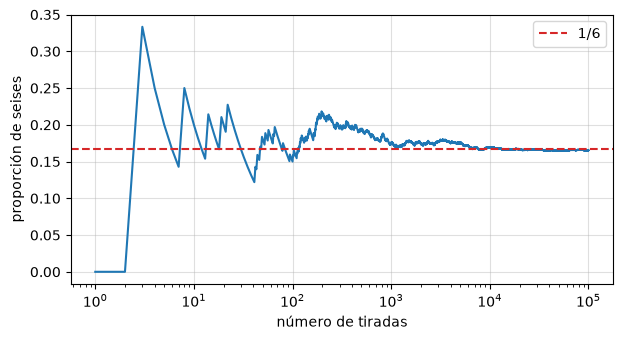

Tras 100.000 tiradas: 0.1654 (y 1/6 = 0.1667)


In [2]:
tiradas = generador.integers(1, 7, size=100_000)
seises_acumulados = np.cumsum(tiradas == 6)               # cuántos seises llevamos tras cada tirada
numero_de_tirada = np.arange(1, len(tiradas) + 1)
proporcion = seises_acumulados / numero_de_tirada

plt.figure(figsize=(7, 3.5))
plt.plot(numero_de_tirada, proporcion, color="tab:blue")
plt.axhline(1 / 6, color="tab:red", linestyle="--", label="1/6")
plt.xscale("log")                                         # escala logarítmica en el eje x (NB18)
plt.xlabel("número de tiradas")
plt.ylabel("proporción de seises")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

print(f"Tras 100.000 tiradas: {proporcion[-1]:.4f} (y 1/6 = {1/6:.4f})")

Al principio, la proporción da saltos enormes (con 1, 2 o 10 tiradas, cualquier cosa es posible). Pero a medida que tiramos más, se va **calmando** y se
pega a la línea roja, **1/6**. Este fenómeno tiene nombre: la **ley de los grandes números**: con muchas repeticiones, la proporción observada se acerca a la
probabilidad de verdad.

Es la razón profunda de todo lo que hacemos al evaluar robots: **un episodio no dice nada; muchos episodios dicen mucho.**


## 2 · La distribución: todas las probabilidades a la vez

Un dado tiene seis resultados posibles, cada uno con su probabilidad. A la lista de **todos** los resultados posibles con sus probabilidades se le llama
**distribución de probabilidad**. La del dado es muy aburrida (todos 1/6):

| Resultado | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---|---|---|---|---|---|
| Probabilidad | 1/6 | 1/6 | 1/6 | 1/6 | 1/6 | 1/6 |

Fíjate en una regla que cumple **toda** distribución: **las probabilidades suman 1** (algo tiene que salir, seguro).

Una más interesante: lanza **dos** dados y **suma** los resultados. ¿Qué suma es más probable? Podemos responder de dos formas. **Contando**: hay 6 × 6 = 36
combinaciones posibles, todas igual de probables; contemos cuántas dan cada suma (con `itertools.product`, NB26):


In [3]:
import itertools
from collections import Counter

sumas = Counter(a + b for a, b in itertools.product(range(1, 7), range(1, 7)))
for suma in range(2, 13):
    print(f"suma {suma:>2}: {sumas[suma]} de 36  ->  probabilidad {sumas[suma] / 36:.3f}  " + "█" * sumas[suma])

suma  2: 1 de 36  ->  probabilidad 0.028  █
suma  3: 2 de 36  ->  probabilidad 0.056  ██
suma  4: 3 de 36  ->  probabilidad 0.083  ███
suma  5: 4 de 36  ->  probabilidad 0.111  ████
suma  6: 5 de 36  ->  probabilidad 0.139  █████
suma  7: 6 de 36  ->  probabilidad 0.167  ██████
suma  8: 5 de 36  ->  probabilidad 0.139  █████
suma  9: 4 de 36  ->  probabilidad 0.111  ████
suma 10: 3 de 36  ->  probabilidad 0.083  ███
suma 11: 2 de 36  ->  probabilidad 0.056  ██
suma 12: 1 de 36  ->  probabilidad 0.028  █


El **7** es lo más probable: 6 de las 36 combinaciones lo dan (1+6, 2+5, 3+4, 4+3, 5+2, 6+1), una de cada seis. El 2 y el 12, lo menos (solo 1+1 y 6+6). La forma
es un **triángulo**: los valores del medio son los más probables, porque se pueden formar de más maneras.

Y la otra forma, **simulando** (tirar los dos dados muchísimas veces y contar), da lo mismo, como dice la ley de los grandes números:


In [4]:
dos_dados = generador.integers(1, 7, size=100_000) + generador.integers(1, 7, size=100_000)
print(f"Proporción de sietes simulada: {(dos_dados == 7).mean():.3f}  (exacta: {6/36:.3f})")

Proporción de sietes simulada: 0.168  (exacta: 0.167)


Cuando contar es fácil, se cuenta; cuando es imposible (como en un robot, donde las "combinaciones" son infinitas), **se simula**. Esa segunda forma se llama, en
general, **método de Montecarlo** (por el casino de Montecarlo, por eso de los dados), y es lo que haces cada vez que evalúas una política jugando muchos episodios.


## 3 · El valor esperado: la media "de verdad"

Si tiras un dado muchísimas veces y haces la **media** de los resultados, ¿a qué número se acerca? Para saberlo sin tirar, se multiplica **cada resultado por su
probabilidad**, y se suma todo:

```
   valor esperado = 1 × 1/6 + 2 × 1/6 + 3 × 1/6 + 4 × 1/6 + 5 × 1/6 + 6 × 1/6 = 21/6 = 3,5
```

A este número se le llama **valor esperado** (o **esperanza**): la media que saldría a la larga. ¿Te suena la forma de la cuenta, "multiplica por parejas y suma"?
¡Es un **producto escalar** (NB13) entre los resultados y sus probabilidades! Las probabilidades son los **pesos** de una media ponderada:


In [5]:
resultados = np.array([1, 2, 3, 4, 5, 6])
probabilidades = np.full(6, 1 / 6)
print("Valor esperado (producto escalar):", resultados @ probabilidades)
print("Media de 100.000 tiradas simuladas:", tiradas.mean())

Valor esperado (producto escalar): 3.5
Media de 100.000 tiradas simuladas: 3.49802


**3,5** exacto, y la simulación da casi lo mismo. Fíjate en un detalle curioso: **el valor esperado de un dado (3,5) es un número que el dado nunca puede sacar**.
No es "lo que va a salir"; es **la media a la larga**.

**Esto es lo que de verdad maximiza el aprendizaje por refuerzo.** El retorno de un episodio es **al azar** (depende del viento, y de las acciones al azar de una
política que explora). Así que un robot no puede aspirar a sacar siempre lo máximo; lo que se busca es la política con el **mayor retorno esperado**: el que sacaría
**de media**, si jugara muchísimos episodios. Cuando en el NB04 decíamos "el robot persigue el retorno", lo preciso es: **persigue el retorno esperado**.


## 4 · La dispersión: varianza y desviación típica

Dos políticas pueden tener **el mismo** retorno esperado y ser muy distintas. Imagina dos robots, ambos con una media de 300 puntos:

- El robot A saca siempre entre 290 y 310.
- El robot B saca a veces 500 y a veces 100.

La media no lo dice, pero B es mucho más **impredecible** (y, en un robot real, más peligroso: a veces se cae). Hace falta un segundo número que mida **cuánto se
dispersan** los resultados alrededor de la media. La receta:

1. Para cada dato, mira **cuánto se aleja** de la media (dato − media).
2. **Elévalo al cuadrado** (para que los alejamientos por arriba y por abajo no se compensen: el truco de siempre, NB04 y NB18).
3. Haz la **media** de esos cuadrados. Eso es la **varianza**.
4. Haz la **raíz cuadrada** (NB12), para volver a las unidades de los datos. Eso es la **desviación típica**, que se escribe con la letra griega **σ** (*sigma*).

Hagámoslo a mano con los dos robots:


In [6]:
robot_a = np.array([290, 300, 310, 295, 305])
robot_b = np.array([500, 100, 480, 120, 300])

for nombre, datos in [("A", robot_a), ("B", robot_b)]:
    media = datos.mean()
    alejamientos = datos - media
    varianza = (alejamientos ** 2).mean()
    desviacion = np.sqrt(varianza)
    print(f"Robot {nombre}: media {media:.0f} | varianza {varianza:8.1f} | desviación típica {desviacion:6.1f} | NumPy: {datos.std():6.1f}")

Robot A: media 300 | varianza     50.0 | desviación típica    7.1 | NumPy:    7.1
Robot B: media 300 | varianza  28960.0 | desviación típica  170.2 | NumPy:  170.2


Misma media (300), pero el robot A tiene una desviación típica de unos **7** puntos y el B, de **unos 170**. NumPy la calcula directamente con `.std()` (de *standard
deviation*), y coincide con nuestra cuenta.

Léela así: **la desviación típica es, más o menos, lo que se aleja un dato "típico" de la media.** Los datos del robot A suelen estar a unos 7 puntos de 300; los del B, a
unos 170. (En el NB27, la política "solo inclinación" tenía una desviación enorme; la "a mano", cero: siempre lo mismo.)


## 5 · El azar continuo: la uniforme y los histogramas

Los dados dan números **sueltos** (1, 2, 3...). Pero mucho azar en robótica da números **continuos**, con decimales: el viento del palo de escoba podía valer 12,7 o
−3,0841... Recuerda que lo fabricábamos con `uniform(-30, 30)` (NB11): cualquier número entre −30 y 30, **todos igual de probables**. Esa es la distribución
**uniforme**.

Para "ver" una distribución continua, se usa un **histograma**: se divide el rango en "cajones" y se dibuja una barra por cajón, tan alta como cuántos datos cayeron en
él. Dibujemos 100.000 vientos:


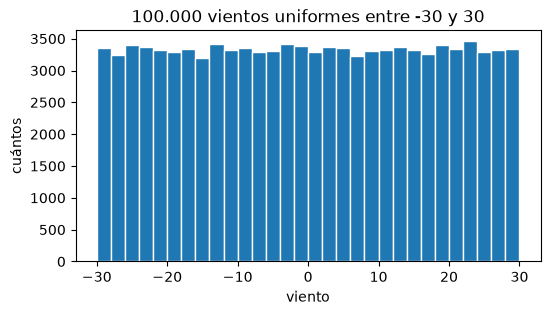

media 0.03 | desviación típica 17.32


In [7]:
vientos = generador.uniform(-30, 30, size=100_000)

plt.figure(figsize=(6, 3))
plt.hist(vientos, bins=30, color="tab:blue", edgecolor="white")
plt.xlabel("viento")
plt.ylabel("cuántos")
plt.title("100.000 vientos uniformes entre -30 y 30")
plt.show()

print(f"media {vientos.mean():.2f} | desviación típica {vientos.std():.2f}")

(`plt.hist` hace el histograma, con 30 cajones: `bins=30`.) Un **rectángulo**: todos los valores entre −30 y 30 salen más o menos con la misma frecuencia, y fuera de ese
rango, ninguno. La media sale casi 0 (el viento sopla igual a un lado que al otro) y la desviación típica, unos 17.


## 6 · La campana de Gauss

Y ahora, la distribución más importante de todas. Haz este experimento: suma **muchos** números uniformes y mira cómo se distribuye la suma. Por ejemplo, el empujón total
que recibe el palo en 20 pasos seguidos de viento:


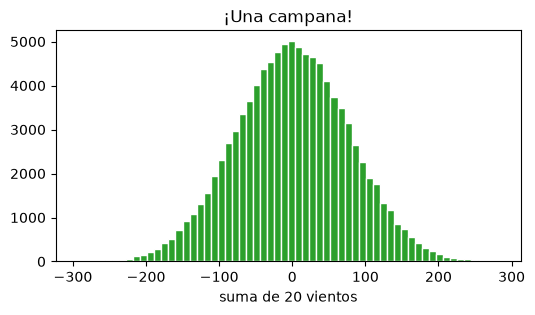

In [8]:
sumas_de_20 = generador.uniform(-30, 30, size=(100_000, 20)).sum(axis=1)     # 100.000 sumas de 20 vientos (axis, NB27)

plt.figure(figsize=(6, 3))
plt.hist(sumas_de_20, bins=60, color="tab:green", edgecolor="white")
plt.xlabel("suma de 20 vientos")
plt.title("¡Una campana!")
plt.show()

Aunque cada viento es un rectángulo, la **suma** de muchos tiene forma de **campana**: muchos valores cerca del centro, y cada vez menos hacia los extremos. (¿Recuerdas los
dos dados? Ya la suma de dos daba un triángulo; con más, se redondea en campana.)

Esto no es casualidad: es uno de los resultados más asombrosos de las matemáticas, el **teorema central del límite**: **la suma de muchas cosas al azar, sean como sean,
tiende a tener forma de campana.** Por eso esta forma aparece **en todas partes**: las estaturas de las personas (suma de muchos factores), los errores de medida de un
sensor (suma de muchas pequeñas perturbaciones), el ruido...

Esta campana se llama **distribución normal** o **campana de Gauss** (por el matemático del NB07, el niño que sumó del 1 al 100). Se describe con **solo dos números**:

- La **media**, μ (*mu*): dónde está el centro de la campana.
- La **desviación típica**, σ (*sigma*): cómo de ancha es.

NumPy fabrica números normales con `generador.normal(media, desviacion, size=...)` (lo usaste en el NB25 y el NB27). Comparemos campanas de distinta σ:


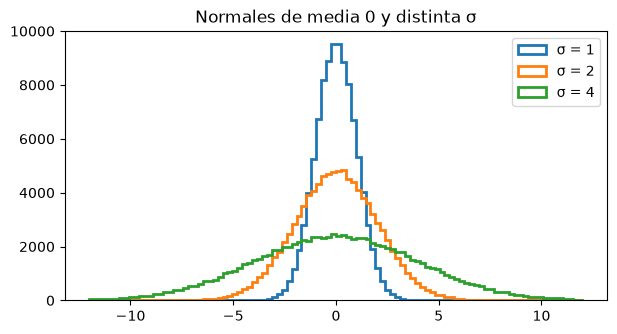

In [9]:
plt.figure(figsize=(7, 3.5))
for sigma, color in [(1, "tab:blue"), (2, "tab:orange"), (4, "tab:green")]:
    muestras = generador.normal(0, sigma, size=100_000)
    plt.hist(muestras, bins=100, range=(-12, 12), histtype="step", linewidth=2, color=color, label=f"σ = {sigma}")
plt.legend()
plt.title("Normales de media 0 y distinta σ")
plt.show()

Las tres centradas en 0 (misma media), pero con σ = 1 la campana es estrecha y alta (los valores se quedan cerca de 0), y con σ = 4 es ancha y baja (los valores se alejan
más). **σ controla cuánto se dispersa el azar.** Esto será la clave de la exploración, en el apartado 9.


### La regla del 68-95-99,7

La campana de Gauss tiene una propiedad muy práctica, siempre la misma sea cual sea su media y su σ:

- Alrededor del **68 %** de los valores caen a menos de **1 σ** de la media.
- Alrededor del **95 %**, a menos de **2 σ**.
- Alrededor del **99,7 %**, a menos de **3 σ** (casi todos).

Comprobémoslo simulando:


In [10]:
muestras = generador.normal(100, 15, size=1_000_000)       # media 100, σ 15
for k in [1, 2, 3]:
    dentro = (np.abs(muestras - 100) < k * 15).mean()
    print(f"a menos de {k} σ: {dentro:.1%}")

a menos de 1 σ: 68.4%
a menos de 2 σ: 95.5%
a menos de 3 σ: 99.7%


**68,4 %, 95,5 % y 99,7 %** (con un millón de muestras, casi exactos). Esta regla permite razonar rapidísimo: si un sensor tiene un error normal con σ = 0,5 grados, sabes que casi nunca se equivocará en más de 1,5
grados (3 σ). Y si un dato está a **más de 3 σ** de la media, es tan raro que merece la pena sospechar de él.


### La fórmula de la campana

Por si te preguntas cómo es la campana "por dentro", tiene una fórmula. Necesita un número especial nuevo, **e** ≈ 2,718 (el **número de Euler**, tan famoso en matemáticas como
π), y la operación de elevarlo a algo, **e elevado a x**, que se llama la **función exponencial**, `np.exp(x)`. La altura de la campana en cada punto x es:

```
                       1                 (x − μ)²
   altura(x)  =  ─────────────  ×  e^( − ────────── )
                  σ × √(2π)                2 σ²
```

No hace falta que la memorices. Lo importante es su forma: el trozo `(x − μ)²` es "cuánto se aleja x del centro, al cuadrado" (otra vez el cuadrado), y la exponencial de
menos eso hace que la altura **caiga muy deprisa** al alejarse del centro. Comprobemos que dibuja la campana de los datos:


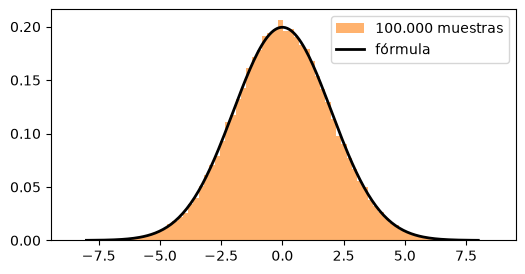

In [11]:
def campana(x, media, sigma):
    return 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-(x - media) ** 2 / (2 * sigma ** 2))

muestras = generador.normal(0, 2, size=100_000)
xs = np.linspace(-8, 8, 200)

plt.figure(figsize=(6, 3))
plt.hist(muestras, bins=80, density=True, color="tab:orange", alpha=0.6, label="100.000 muestras")
plt.plot(xs, campana(xs, 0, 2), color="black", linewidth=2, label="fórmula")
plt.legend()
plt.show()

La fórmula (línea negra) calca el histograma. (`density=True` escala el histograma para que su área total valga 1, como la de la fórmula. Y `np.pi` es π.)

A esta "altura" se le llama **densidad de probabilidad**: no es la probabilidad de un valor exacto (que, con infinitos decimales posibles, es prácticamente 0), sino **cómo de
concentrados** están los valores en cada zona. Donde la campana es más alta, más valores caen cerca.


## 7 · ¿Cuánto fiarse de una media?

En el NB27 descubriste que evaluar una política con 5 episodios engaña. Ahora podemos decir **cuánto**. Cuando haces la media de **n** datos al azar, esa media **también** es al
azar (con otros datos, saldría otra). ¿Cuánto se dispersa? Hay una regla preciosa:

> **La desviación típica de una media de n datos es σ / √n** (la desviación de los datos, dividida entre la raíz cuadrada de cuántos hay).

Se llama **error típico** de la media. Con 4 datos, la media se dispersa la **mitad** que un dato suelto (√4 = 2); con 100, **diez veces menos** (√100 = 10). Comprobémoslo con un
"robot" cuyos retornos tienen media 300 y σ 150 (algo así como la política "solo inclinación"). Imagina mil ingenieros que lo evalúan, cada uno con 5 episodios, y otros mil, con
100:


In [12]:
sigma = 150
for n in [5, 100]:
    medias = generador.normal(300, sigma, size=(1000, n)).mean(axis=1)    # 1000 ingenieros, cada uno con n episodios
    print(f"con {n:>3} episodios: las medias se dispersan {medias.std():5.1f}  (σ/√n = {sigma / np.sqrt(n):5.1f}) | "
          f"van de {medias.min():.0f} a {medias.max():.0f}")

con   5 episodios: las medias se dispersan  66.9  (σ/√n =  67.1) | van de 82 a 516
con 100 episodios: las medias se dispersan  15.3  (σ/√n =  15.0) | van de 254 a 356


Con **5** episodios, las medias de los mil ingenieros se dispersan unos **67 puntos**: unos dirían que el robot saca 200, otros que 400... ¡del mismo robot! Con **100**, solo unos
**15**: todos coinciden en torno a 300. Y las dos cifras casan con la fórmula σ/√n.

Esto da una regla práctica muy usada para decir cuánto fiarse de una media (por la regla del 95 % del apartado anterior):

> **El valor de verdad está, casi seguro (un 95 %), entre media − 2·σ/√n y media + 2·σ/√n.** A ese rango se le llama **intervalo de confianza**.

Cuando un artículo científico de robótica dice "nuestro método saca 455 ± 12", a menudo se refiere a algo así. Y si dos políticas tienen intervalos que se solapan mucho, **no puedes
afirmar que una sea mejor que la otra**: la diferencia podría ser solo suerte. Es una de las costumbres que más distinguen a un profesional de un aficionado.


## 8 · La política que explora

Y llegamos a la aplicación que necesitamos para el próximo notebook. En el NB03 dijimos que, mientras aprende, una política tiene que **explorar**: probar acciones un poco distintas de
las que cree mejores, para descubrir si hay algo mejor. Ahora sabemos cómo hacerlo con precisión: en vez de dar **una** acción fija, la política da una **campana de Gauss** de acciones,
y **sortea** la acción de esa campana.

```
   acción = la que la política cree mejor (la media, μ)  +  σ × (un número normal de media 0 y σ 1)
```

- La **media** μ es lo que daría la política "normal" (por ejemplo, −30 × inclinación − 8 × velocidad).
- **σ** decide **cuánto explora**: con σ = 0, siempre hace lo mismo; con σ grande, prueba cosas muy distintas.

A una política así, que sortea sus acciones, se le llama **política estocástica** ("estocástico" = "al azar"). La del NB11 era **determinista** (siempre la misma acción ante la misma
observación). Probemos el palo de escoba con la política a mano **con exploración**, para varias σ, usando la versión de mil palos a la vez del NB27 (con la acción sorteada de la campana):


In [13]:
def evaluar_estocastica(k, d, sigma, n_palos=1000, semilla=0):
    generador = np.random.default_rng(semilla)
    inclinacion = np.full(n_palos, 2.0)
    velocidad = np.zeros(n_palos)
    vivos = np.ones(n_palos, dtype=bool)
    retornos = np.zeros(n_palos)
    for paso in range(500):
        media = -k * inclinacion - d * velocidad                              # lo que la política "cree mejor"
        accion = media + sigma * generador.standard_normal(n_palos)          # ...más un poco de azar
        empuje = np.clip(accion, -40, 40)
        aceleracion = 10 * inclinacion + empuje + generador.uniform(-30, 30, n_palos)
        velocidad = velocidad + aceleracion * 0.02
        inclinacion = inclinacion + velocidad * 0.02
        vivos = vivos & (np.abs(inclinacion) <= 30)
        retornos = retornos + np.where(vivos, 1 - (inclinacion / 30) ** 2, 0.0)
    return retornos

for sigma in [0, 20, 50, 100, 200]:
    r = evaluar_estocastica(30, 8, sigma)
    print(f"σ = {sigma:>2}: retorno medio {r.mean():6.1f} | desviación {r.std():6.1f}")

σ =  0: retorno medio  499.9 | desviación    0.0
σ = 20: retorno medio  499.9 | desviación    0.0
σ = 50: retorno medio  497.8 | desviación   25.0
σ = 100: retorno medio  139.8 | desviación   79.6
σ = 200: retorno medio   71.1 | desviación   21.0


(`standard_normal` da números normales de media 0 y σ 1, la "campana estándar"; multiplicarlos por σ la ensancha.)

Explorar **tiene un coste**: cuanto más azar añades a las acciones, peor juega la política **en ese momento**, porque a veces hace cosas peores de las que sabe. La política a mano es muy
**robusta**: con σ = 20, ni se inmuta, y con σ = 50 apenas pierde un par de puntos (corrige enseguida los errores que mete el azar). Pero con σ = 100 (acciones que se alejan
muchísimo de lo sensato) se **desploma**: se cae casi siempre. Y con σ = 200 juega prácticamente al azar. Es el dilema **explorar contra aprovechar** del NB03, ahora con un número que lo controla: **σ**.

Al principio del entrenamiento, cuando la política aún no sabe nada, interesa explorar mucho; al final, cuando ya sabe, interesa explorar poco. Y cuando la entrenemos de verdad,
**σ también podrá aprenderse**: la propia política decidirá cuánto explorar.


## 9 · Una herramienta para el próximo notebook: el logaritmo

Para el algoritmo del NB29 nos hará falta una última herramienta matemática: el **logaritmo**. No te asustes; la idea es sencilla.

El **logaritmo** es la operación **contraria a la exponencial**: si e elevado a 2 es 7,389, el logaritmo de 7,389 es 2. Es decir, el logaritmo responde a la pregunta "**¿a qué hay que
elevar e para obtener este número?**". En NumPy, `np.log`:


In [14]:
print(np.exp(2))
print(np.log(np.exp(2)))
print(np.log(1))

7.38905609893065
2.0
0.0


El logaritmo deshace la exponencial (y el logaritmo de 1 es 0, porque e elevado a 0 es 1).

¿Para qué sirve? Tiene una propiedad mágica: **convierte las multiplicaciones en sumas**:

```
   log(a × b) = log(a) + log(b)
```


In [15]:
a, b = 0.2, 0.5
print(np.log(a * b), "=", np.log(a) + np.log(b))

-2.3025850929940455 = -2.3025850929940455


¿Y eso para qué? En aprendizaje por refuerzo se trabaja con **probabilidades de secuencias de acciones**: la probabilidad de que una política haga una acción **y** otra **y** otra...
es una **multiplicación** de muchas probabilidades, que da números minúsculos (multiplicar mil números menores que 1 da algo tan pequeño que el ordenador lo redondea a 0). Con logaritmos,
esas multiplicaciones se convierten en **sumas** de números normales, que se manejan sin problema.

Por eso, en vez de la probabilidad (o la densidad) de una acción, los algoritmos usan su **log-probabilidad**. Para una política normal (apartado 8), aplicando el logaritmo a la fórmula de la
campana, la exponencial desaparece y queda algo muy sencillo:

```
   log-probabilidad(acción) = − (acción − μ)² / (2 σ²)  −  log(σ × √(2π))
```

Comprobemos que es el logaritmo de la campana:


In [16]:
def log_probabilidad(accion, media, sigma):
    return -(accion - media) ** 2 / (2 * sigma ** 2) - np.log(sigma * np.sqrt(2 * np.pi))

accion, media, sigma = -55.0, -60.0, 5.0
print(log_probabilidad(accion, media, sigma), "=", np.log(campana(accion, media, sigma)))

-3.028376445638773 = -3.0283764456387727


Iguales. Fíjate en la forma: la log-probabilidad es **más alta** (menos negativa) cuanto **más cerca** está la acción de la media. Una acción justo en la media es la más probable; una muy
alejada, muy improbable.

En el NB29, la pregunta clave será: **¿hacia dónde hay que mover la media de la política para que una acción concreta se vuelva más probable?** Y la respuesta será... la **pendiente** (NB16)
de esta log-probabilidad. Con eso, y las recompensas, el robot aprenderá solo.


## 10 · Resumen de la lección

1. La **probabilidad** es la proporción de veces que pasa algo a la larga (de 0 a 1). Con muchas repeticiones, lo observado se acerca a la probabilidad: **ley de los grandes números**. Una
   **distribución** da todas las probabilidades (suman 1); se calcula contando o **simulando** (Montecarlo).
2. El **valor esperado** = suma de valor × probabilidad (un producto escalar): la media a la larga (3,5 en un dado). **El RL maximiza el retorno esperado.**
3. La **varianza** (media de los alejamientos al cuadrado) y la **desviación típica σ** (su raíz) miden la **dispersión**. Distribuciones continuas: **uniforme** (el viento) y **normal** o
   **campana de Gauss** (media μ, anchura σ; regla 68-95-99,7; aparece al sumar muchos azares: **teorema central del límite**; fórmula con **e** y la **exponencial**).
4. Una media de n datos se dispersa **σ/√n** (**error típico**): 5 episodios engañan, 100 mucho menos. **Intervalo de confianza** ≈ media ± 2·σ/√n.
5. **Política estocástica**: acción = media + σ × ruido normal; σ controla la **exploración** (y explorar cuesta retorno). El **logaritmo** (inverso de la exponencial) convierte productos en
   sumas; la **log-probabilidad** de una normal es −(a − μ)²/(2σ²) − log(σ√(2π)).

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Probabilidad** | Proporción de veces que pasa algo, a la larga (de 0 a 1). |
| **Ley de los grandes números** | Con muchas repeticiones, lo observado se acerca a la probabilidad. |
| **Distribución** | Todos los resultados posibles con sus probabilidades. |
| **Montecarlo** | Calcular algo simulando muchas veces al azar. |
| **Valor esperado / esperanza** | La media a la larga: suma de valor × probabilidad. |
| **Varianza / desviación típica (σ)** | Cuánto se dispersan los datos alrededor de la media. |
| **Uniforme / normal (Gauss)** | Todos igual de probables en un rango / la campana. |
| **Histograma** | Dibujo de barras de cuántos datos caen en cada "cajón". |
| **Teorema central del límite** | La suma de muchos azares tiende a ser una campana. |
| **e / exponencial** | El número 2,718... / elevar e a algo (`np.exp`). |
| **Densidad de probabilidad** | La "altura" de una distribución continua. |
| **Error típico** | La dispersión de una media: σ/√n. |
| **Intervalo de confianza** | Rango donde casi seguro está el valor de verdad: media ± 2σ/√n. |
| **Política estocástica / determinista** | Que sortea sus acciones / que siempre da la misma. |
| **Logaritmo** | La operación inversa de la exponencial (`np.log`). |
| **Log-probabilidad** | El logaritmo de la probabilidad (o densidad) de una acción. |


## 11 · Ejercicios

**E1.** ¿Cuál es la probabilidad de sacar un número **par** con un dado? ¿Y de que la suma de dos dados sea **12**? Compruébalo simulando.

**E2.** Calcula el valor esperado de un "dado trucado" que saca 6 la mitad de las veces y cualquiera de los otros cinco números con probabilidad 1/10 cada uno. (Comprueba primero que las
probabilidades suman 1.)

**E3.** Calcula a mano la media y la desviación típica de los retornos `[2, 4, 4, 4, 5, 5, 7, 9]`. Compruébalo con NumPy.

**E4.** Si un sensor de inclinación tiene un error normal de media 0 y σ = 0,2 grados, ¿entre qué valores estará el error el 95 % de las veces?

**E5.** Una política tiene retornos con σ = 100. ¿Cuántos episodios necesitas para que el error típico de la media sea de unos 10 puntos?

**E6.** Dos políticas: A saca 450 de media en 20 episodios y B, 470 en 20 episodios; las dos con σ ≈ 60. ¿Puedes afirmar que B es mejor? Calcula sus intervalos de confianza.

**E7.** Comprueba con NumPy que `log(8) = log(2) + log(4)`, y que `np.exp(np.log(5))` da 5.

**E8.** **Reto.** Con `evaluar_estocastica`, busca a partir de qué σ el retorno medio de la política a mano baja de 400.


<details>
<summary>▶ Solución E1</summary>

Par: tres de seis resultados (2, 4, 6) → **1/2**. Suma 12: solo 6+6, una de 36 combinaciones → **1/36 ≈ 0,028**.

```python
g = np.random.default_rng(1)
d = g.integers(1, 7, size=100_000)
print((d % 2 == 0).mean())                                                          # ≈ 0.5
print((g.integers(1, 7, 100_000) + g.integers(1, 7, 100_000) == 12).mean())        # ≈ 0.028
```

(`d % 2 == 0` es "el resto de dividir entre 2 es 0", es decir, par: NB21.)
</details>

<details>
<summary>▶ Solución E2</summary>

Probabilidades: 5 × 1/10 + 1/2 = 0,5 + 0,5 = **1**. ✓ Valor esperado: (1 + 2 + 3 + 4 + 5) × 0,1 + 6 × 0,5 = 1,5 + 3 = **4,5**. Más alto que el 3,5 del dado normal, claro: el 6 sale más.

```python
print(np.array([1, 2, 3, 4, 5, 6]) @ np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.5]))     # 4.5
```
</details>

<details>
<summary>▶ Solución E3</summary>

Media: (2+4+4+4+5+5+7+9)/8 = 40/8 = **5**. Alejamientos al cuadrado: 9, 1, 1, 1, 0, 0, 4, 16 → suma 32 → varianza 32/8 = 4 → desviación típica √4 = **2**.

```python
x = np.array([2, 4, 4, 4, 5, 5, 7, 9])
print(x.mean(), x.std())     # 5.0 2.0
```
</details>

<details>
<summary>▶ Solución E4</summary>

El 95 % de los valores de una normal caen a menos de 2 σ de la media: entre **−0,4 y +0,4 grados**.
</details>

<details>
<summary>▶ Solución E5</summary>

Queremos σ/√n ≈ 10 → √n ≈ 100/10 = 10 → **n ≈ 100** episodios. (Para la mitad de error, 5 puntos, harían falta 400: el cuádruple. Mejorar la precisión sale caro.)
</details>

<details>
<summary>▶ Solución E6</summary>

Error típico de cada una: 60/√20 ≈ 13,4. Intervalos (± 2 errores típicos): A, de 450 − 27 a 450 + 27, es decir, **[423, 477]**; B, **[443, 497]**. **Se solapan muchísimo**: con solo 20
episodios, no puedes afirmar que B sea mejor; la diferencia de 20 puntos podría ser suerte. Para distinguirlas harían falta muchos más episodios.
</details>

<details>
<summary>▶ Solución E7</summary>

```python
print(np.log(8), np.log(2) + np.log(4))     # iguales (2.079...)
print(np.exp(np.log(5)))                    # 5.0 (con su ruidito de decimales, quizá)
```
</details>

<details>
<summary>▶ Solución E8</summary>

```python
for sigma in [50, 60, 70, 80, 90, 100]:
    print(sigma, round(evaluar_estocastica(30, 8, sigma).mean(), 1))
```

Con σ = 50 aún saca unos 498, y con σ = 100 ya se ha desplomado a unos 140: la caída por debajo de 400 está **entre σ = 60 (unos 470) y σ = 70 (unos 374)**. Fíjate en que la caída es **brusca**: la política aguanta el ruido muy bien... hasta que deja de poder corregirlo, y entonces se hunde. La lección: **explorar mucho sale caro**.
Por eso, en un entrenamiento, la exploración suele empezar grande e ir **disminuyendo** a medida que la política aprende.
</details>


## 12 · 🛠 Práctica en MuJoCo: tirar los dados con física de verdad

Toda la lección ha girado en torno a una idea: **el mismo experimento, repetido, no da siempre lo mismo**, y hay que medirlo con
medias, desviaciones, histogramas e intervalos. Hoy lo comprobarás en **MuJoCo**, con el palo de escoba de física real
(`taller.cargar("palo_escoba")`: un carrito sobre un raíl, un palo de 1 m sujeto con una bisagra y un motor que empuja el carrito).

Vas a descubrir algo curioso: **MuJoCo no tira dados**. Si le das exactamente la misma situación, da exactamente el mismo resultado,
siempre. Entonces, ¿de dónde sale el azar en un entrenamiento de robots? De **dos sitios**, los dos del apartado 1: de **dónde
empieza** el robot (cada episodio, un poco distinto) y de la **política que explora**. Los dos los vas a controlar tú con un
**generador** y su **semilla**.

Recordatorio del palo de MuJoCo: `datos.qpos` tiene dos números, la posición del carro (metros) y el **ángulo del palo** (en
**radianes**, NB03b); `datos.qvel`, sus dos velocidades. Diremos que el palo **se ha caído** cuando pase de **30 grados**, como
en el palo de siempre.


### Paso 1 · Cargar el palo de escoba

Lo de siempre: el **modelo** (el plano, que no cambia) y unos **datos** (el estado de ahora). El paso de tiempo de este mundo es
de una centésima de segundo.


In [17]:
import mujoco
import taller

modelo, datos = taller.cargar("palo_escoba")
print("Paso de tiempo:", modelo.opt.timestep, "s")
print("qpos (carro, ángulo):", datos.qpos)

Paso de tiempo: 0.01 s
qpos (carro, ángulo): [0. 0.]


### Paso 2 · Una función que mide cuánto tarda en caer

Con lo que sabes de funciones (NB10), bucles `while` (NB07) y radianes (NB03b): un **mundo nuevo** (`mujoco.MjData(modelo)`, un
estado recién estrenado), el palo torcido `angulo` grados, **sin motor**, y pasitos hasta que pase de 30 grados (o hasta 5 segundos).
Devuelve el tiempo que tardó.


In [18]:
def tiempo_de_caida(angulo, segundos_max=5.0):
    datos = mujoco.MjData(modelo)                  # un episodio nuevo, desde cero
    datos.qpos[1] = np.radians(angulo)             # el palo, torcido (MuJoCo quiere radianes)
    while datos.time < segundos_max:
        mujoco.mj_step(modelo, datos)
        if abs(np.degrees(datos.qpos[1])) > 30:    # ¿se ha caído?
            return datos.time
    return segundos_max

### Paso 3 · MuJoCo no tira dados

Lancemos **tres veces** el mismo experimento: el palo torcido 5 grados.


In [19]:
for intento in range(3):
    print(f"intento {intento}: cae en {tiempo_de_caida(5):.2f} s")

intento 0: cae en 0.58 s
intento 1: cae en 0.58 s
intento 2: cae en 0.58 s


**0,58 s las tres veces**, clavado. Un simulador es **determinista**: mismas condiciones, mismo resultado (por eso se pueden
repetir los experimentos y cazar errores, NB27). Y mira cómo cambia con el ángulo de partida:


In [20]:
for angulo in [5, 1, 0.1, 0]:
    print(f"torcido {angulo:>3} grados: cae en {tiempo_de_caida(angulo):.2f} s")

torcido   5 grados: cae en 0.58 s
torcido   1 grados: cae en 0.95 s
torcido 0.1 grados: cae en 1.49 s
torcido   0 grados: cae en 5.00 s


Cuanto más derecho empieza, más tarda: desde 1 grado, casi un segundo; desde una décima, 1,5 s. Y desde **0 exactos** no se cae
**nunca** (los 5 s del máximo): un palo perfectamente vertical, sin nada que lo empuje, se queda en equilibrio para siempre... en
un simulador. En el mundo real siempre hay un soplo de aire, una vibración, un error de un milímetro. Por eso, para que el robot
aprenda a manejar el mundo real, **el azar hay que ponerlo nosotros**.


### Paso 4 · El azar, en el estado inicial

Cada episodio empezará con el palo torcido un ángulo **uniforme** (apartado 5) entre −5 y +5 grados, sorteado con un generador con
**semilla** (NB11). Mil episodios (tarda unos segundos):


In [21]:
generador = np.random.default_rng(0)
angulos = generador.uniform(-5, 5, size=1000)
tiempos = np.array([tiempo_de_caida(a) for a in angulos])

print(f"media {tiempos.mean():.3f} s | desviación típica {tiempos.std():.3f} s")
print(f"el más rápido {tiempos.min():.2f} s | el más lento {tiempos.max():.2f} s")

media 0.814 s | desviación típica 0.236 s
el más rápido 0.58 s | el más lento 2.85 s


Una media de unos **0,81 s**, con una desviación de unos **0,24 s**. El más rápido, 0,58 s (los que empezaron casi a 5
grados); el más lento, casi **3 segundos** (alguno que empezó casi derecho del todo).


### Paso 5 · El histograma: no todo es una campana

Dibujemos la **distribución** de los tiempos (apartado 5):


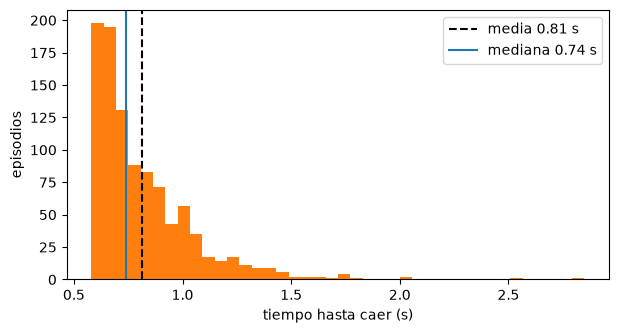

In [22]:
plt.figure(figsize=(7, 3.5))
plt.hist(tiempos, bins=40, color="tab:orange")
plt.axvline(tiempos.mean(), color="black", linestyle="--", label=f"media {tiempos.mean():.2f} s")
plt.axvline(np.median(tiempos), color="tab:blue", label=f"mediana {np.median(tiempos):.2f} s")
plt.xlabel("tiempo hasta caer (s)")
plt.ylabel("episodios")
plt.legend()
plt.show()

¡No es una campana de Gauss! Es una montaña pegada a la izquierda (nadie baja de 0,58 s) con una **cola larga** hacia la derecha:
unos pocos episodios que empezaron casi derechos duran muchísimo. En distribuciones así, la media (0,81) queda por encima de la
**mediana** (`np.median`, el valor que deja la mitad de los datos a cada lado: unos 0,74 s), porque la cola tira de ella. Muchas
cosas en robótica tienen colas así (la duración de los episodios, sobre todo), y por eso conviene **mirar el histograma**, no
solo la media.

(Aunque los tiempos no sean una campana, la **media** de muchos de ellos sí se comporta como una: el teorema central del límite del
apartado 6. Por eso el error típico del paso siguiente vale igual.)


### Paso 6 · ¿Cuánto fiarse de la media? (y la semilla)

El error típico (apartado 7) de estos mil episodios, y el intervalo de confianza del 95 %:


In [23]:
error = tiempos.std() / np.sqrt(len(tiempos))
print(f"media {tiempos.mean():.3f} ± {2 * error:.3f} s  → entre {tiempos.mean() - 2 * error:.3f} y {tiempos.mean() + 2 * error:.3f}")

media 0.814 ± 0.015 s  → entre 0.799 y 0.829


Con mil episodios, la media del tiempo de caída está casi seguro entre **0,80 y 0,83 s**. Ahora, el papel de la **semilla**.
Tres "ingenieros" que solo miran **10** episodios cada uno, con semillas distintas... y uno que repite la semilla 0:


In [24]:
for semilla in [0, 1, 2, 0]:
    g = np.random.default_rng(semilla)
    diez = np.array([tiempo_de_caida(a) for a in g.uniform(-5, 5, size=10)])
    print(f"semilla {semilla}: media de 10 episodios = {diez.mean():.3f} s | los tres primeros: {diez[:3]}")

semilla 0: media de 10 episodios = 0.759 s | los tres primeros: [0.88 0.76 0.6 ]
semilla 1: media de 10 episodios = 0.848 s | los tres primeros: [1.45 0.6  0.66]
semilla 2: media de 10 episodios = 0.748 s | los tres primeros: [0.75 0.79 0.69]
semilla 0: media de 10 episodios = 0.759 s | los tres primeros: [0.88 0.76 0.6 ]


Dos lecciones en cuatro líneas:

- **Con la misma semilla, todo se repite exactamente** (la semilla 0 sale dos veces idéntica): los ángulos sorteados son los mismos,
  y MuJoCo, que es determinista, hace lo mismo con ellos. Así se puede **reproducir** un experimento con azar.
- **Con 10 episodios, cada semilla cuenta una historia distinta** (unos 0,76, 0,85, 0,75 s): el error típico de 10 episodios es
  unas 0,24/√10 ≈ 0,08 s. Con mil, todas coincidirían en torno a 0,81. Es la ley de los grandes números, con física de verdad.


### Paso 7 · La política que explora, en MuJoCo

Ahora el otro azar: el de la **política estocástica** (apartado 8). El palo de MuJoCo tiene un buen controlador hecho a mano (lo
verás a fondo en la Parte 5): empuja el carro según el ángulo y la velocidad del palo, y un poquito según dónde está el carro, para
que no se escape del raíl. Ese controlador hará de **media**, y le sumamos σ × (ruido normal), como en el apartado 8. La orden al motor
va de −1 a 1 (`np.clip`).


In [25]:
def aguante(sigma, generador, segundos_max=5.0):
    datos = mujoco.MjData(modelo)
    datos.qpos[1] = np.radians(generador.uniform(-5, 5))         # empieza algo torcido, al azar
    while datos.time < segundos_max:
        x, angulo = datos.qpos
        v, giro = datos.qvel
        media = 3 * angulo + 0.8 * giro + 0.1 * x + 0.2 * v        # lo que la política "cree mejor"
        datos.ctrl[0] = np.clip(media + sigma * generador.standard_normal(), -1, 1)   # ...más azar
        mujoco.mj_step(modelo, datos)
        if abs(np.degrees(datos.qpos[1])) > 30:
            return datos.time
    return segundos_max

(`x, angulo = datos.qpos` reparte los dos números de `qpos` en dos variables de golpe, NB21.)

Cien episodios de 5 segundos para cada σ:


In [26]:
for sigma in [0, 0.5, 1, 2, 5]:
    g = np.random.default_rng(0)
    t = np.array([aguante(sigma, g) for _ in range(100)])
    print(f"σ = {sigma:>3}: aguanta {t.mean():.2f} s de media (desviación {t.std():.2f}) | llega a los 5 s el {(t >= 5).mean():.0%}")

σ =   0: aguanta 5.00 s de media (desviación 0.00) | llega a los 5 s el 100%


σ = 0.5: aguanta 5.00 s de media (desviación 0.00) | llega a los 5 s el 100%


σ =   1: aguanta 4.43 s de media (desviación 0.96) | llega a los 5 s el 64%


σ =   2: aguanta 1.73 s de media (desviación 0.70) | llega a los 5 s el 0%


σ =   5: aguanta 0.83 s de media (desviación 0.29) | llega a los 5 s el 0%


El dilema **explorar contra aprovechar**, ahora con física real:

- Con σ = 0 y σ = 0,5, el palo aguanta los **5 s** en el 100 % de los episodios: el controlador corrige el azar sin despeinarse.
- Con σ = 1, ya se cae en uno de cada tres episodios (aguanta 4,4 s de media, y la desviación se dispara: unos aguantan, otros no).
- Con σ = 2, **nunca** llega al final (1,7 s de media).
- Con σ = 5, el motor va prácticamente al azar (casi siempre a tope a un lado u otro) y el palo cae en 0,8 s: ¡lo mismo que sin motor!

Igual que en el apartado 8: la política aguanta bastante ruido... hasta que deja de poder corregirlo, y se hunde de golpe.


### Paso 8 · Míralo

Dos vídeos de 4 segundos con el mismo palo y el mismo controlador: con poca exploración (σ = 0,5) y con mucha (σ = 2). La función
`control` es la que `taller.video` llama en cada pasito para que escriba la orden del motor en `datos.ctrl`.


In [27]:
def explorador(sigma, semilla):
    g = np.random.default_rng(semilla)
    def control(modelo, datos):
        x, angulo = datos.qpos
        v, giro = datos.qvel
        media = 3 * angulo + 0.8 * giro + 0.1 * x + 0.2 * v
        datos.ctrl[0] = np.clip(media + sigma * g.standard_normal(), -1, 1)
    return control

modelo, datos = taller.cargar("palo_escoba")
datos.qpos[1] = np.radians(4)
taller.video(modelo, datos, segundos=4, control=explorador(0.5, semilla=1), nombre="nb28_poco_azar");

In [28]:
modelo, datos = taller.cargar("palo_escoba")
datos.qpos[1] = np.radians(4)
taller.video(modelo, datos, segundos=4, control=explorador(2, semilla=1), nombre="nb28_mucho_azar");

Con σ = 0,5 el carro tiembla un poco (son los "experimentos" de la exploración) pero el palo sigue de pie. Con σ = 2, el carro
da tirones a lo loco y el palo se cae y acaba **colgando** bajo el carro (en este modelo el palo no choca con nada: atraviesa el
raíl como un fantasma; para aprender a equilibrar no hace falta más). (La función `explorador` fabrica y **devuelve** otra función, `control`, que
recuerda su σ y su generador: es un truco de Python que ya viste en `taller.al_azar`.)


### Tus retos

**R1.** Cambia el rango del ángulo inicial de ±5 a **±15 grados** (en el paso 4) y vuelve a medir la media y la desviación del
tiempo de caída. ¿Más o menos? ¿Por qué?

**R2.** Con el error típico del paso 6: ¿cuántos episodios harían falta para conocer la media del tiempo de caída con un error típico
de **0,001 s**?

**R3.** Con los `tiempos` del paso 4, calcula la **probabilidad** de que el palo aguante **más de 1 segundo** sin motor (como
frecuencia: proporción de episodios).

**R4.** Busca, con `aguante`, la σ a partir de la cual el palo se cae **la mitad** de las veces (prueba entre 1 y 2).


<details>
<summary>▶ Solución R1</summary>

```python
g = np.random.default_rng(0)
t15 = np.array([tiempo_de_caida(a) for a in g.uniform(-15, 15, size=1000)])
print(t15.mean(), t15.std())
```

Medido: unos **0,56 s** de media (antes, 0,81) y la misma desviación, unos **0,24 s**. Cae antes porque, de media, empieza más
torcido; y casi un tercio de los episodios (los que empiezan a más de 5 grados) caen **antes** de 0,58 s, el mínimo de antes.
</details>

<details>
<summary>▶ Solución R2</summary>

Error típico = σ/√n → √n = 0,24 / 0,001 = 240 → **n ≈ 57.600** episodios. Mejorar 7 veces la precisión (de 0,0075 a 0,001) cuesta
unas 50 veces más episodios: la raíz cuadrada es una mala noticia para el bolsillo.
</details>

<details>
<summary>▶ Solución R3</summary>

```python
print((tiempos > 1).mean())
```

Medido: **0,174**, un 17 %. (Son los episodios que empezaron a menos de ~1 grado de la vertical: 2 grados de un rango de 10, un 20 %,
más o menos.)
</details>

<details>
<summary>▶ Solución R4</summary>

```python
for sigma in [1.0, 1.2, 1.4, 1.6, 1.8]:
    g = np.random.default_rng(0)
    t = np.array([aguante(sigma, g) for _ in range(100)])
    print(sigma, (t < 5).mean())
```

Medido: con σ = 1 se cae el 36 % de las veces, y con σ = 1,2 ya el 80 %: la mitad cae hacia **σ ≈ 1,1**. Fíjate en lo estrecha que es la
franja entre "casi nunca se cae" (σ = 0,5) y "siempre se cae" (σ = 2).
</details>


### Qué has aprendido de MuJoCo hoy

- **MuJoCo es determinista**: el mismo estado inicial da exactamente la misma simulación. El azar de un entrenamiento lo pones **tú**.
- `mujoco.MjData(modelo)` fabrica un **episodio nuevo** (un estado limpio) sin volver a cargar el plano: así se juegan mil episodios.
- El azar entra por el **estado inicial** (ángulos sorteados) y por la **política que explora** (σ × ruido en `datos.ctrl`).
- Con un **generador con semilla**, un experimento con azar se repite idéntico; con semillas distintas, se miden las diferencias.
- Los tiempos de caída tienen una **cola larga**: mirar el histograma, no solo la media.

En la práctica del **NB28b** calcularás la **log-probabilidad** de un episodio entero del palo de MuJoCo y comprobarás, con
episodios de verdad, el truco del logaritmo que permite aprender.


## 13 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Hoy has construido la probabilidad desde cero: frecuencias, distribuciones, valor esperado, dispersión, la campana de Gauss, el error típico y las políticas que exploran, y lo has medido con la física real de MuJoCo. En el **NB28b**
deduciremos con lápiz, y comprobaremos, todas las piezas matemáticas que necesita el algoritmo siguiente. Y en el **NB29** juntamos
todo: el primer algoritmo de aprendizaje por refuerzo **de verdad**, **REINFORCE**. Sin maestro, sin probar ruedecillas al azar: el palo de escoba jugará episodios con su política exploradora,
mirará qué acciones salieron mejor de lo normal, y moverá sus ruedecillas para hacerlas **más probables**. Y aprenderá a mantener el palo de pie **desde cero**.
